# Employee Performance Prediction System

This notebook presents a complete machine learning pipeline for predicting employee performance categories based on workplace metrics. The system classifies employees into **Low** or **Medium** performance tiers using five numerical features derived from human resources records.

The project follows a structured methodology encompassing data exploration, preprocessing, model design, training, evaluation, and deployment. Three tree-based classification algorithms — **Decision Tree**, **Random Forest**, and **XGBoost** — are compared through rigorous cross-validated evaluation, and the best-performing model is selected, persisted, and demonstrated on unseen data.

**Dataset:** `employee_data.csv` — 250 employee records with five numerical features and a binary target label.

**Target Variable:** `performance` (Low / Medium)

---
## 1. Import Required Libraries

All libraries used throughout this notebook are imported here to provide a clear dependency overview. The project relies on `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualisation, `scikit-learn` for machine learning modelling and evaluation, `xgboost` for gradient boosting, and `scipy` for statistical testing.

In [1]:
# ── Data Manipulation ──
import pandas as pd
import numpy as np

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Preprocessing & Pipeline ──
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Classification Models ──
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluation Metrics ──
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# ── Statistical Testing ──
from scipy import stats

# ── Model Persistence ──
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150})

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Data Loading and Initial Inspection

The dataset is loaded from `employee_data.csv`. An initial inspection is performed to verify the schema, check data types, identify any missing values, and understand the overall structure before proceeding with deeper analysis.

In [2]:
# Load the dataset
data_path = 'employee_data.csv'
df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumn names: {list(df.columns)}')
print()
df.info()

Dataset shape: 250 rows × 6 columns

Column names: ['attendance_rate', 'task_completion_score', 'experience_years', 'training_hours', 'previous_rating', 'performance']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   attendance_rate        250 non-null    float64
 1   task_completion_score  250 non-null    float64
 2   experience_years       250 non-null    float64
 3   training_hours         250 non-null    float64
 4   previous_rating        250 non-null    float64
 5   performance            250 non-null    object 
dtypes: float64(5), object(1)
memory usage: 11.8+ KB


In [3]:
# Display the first ten records
df.head(10)

,attendance_rate,task_completion_score,experience_years,training_hours,previous_rating,performance
0,88.97,51.09,7.78,15.77,4.12,Low
1,83.89,83.77,10.73,11.48,3.74,Medium
2,90.18,100.00,0.80,15.24,3.05,Medium
3,97.18,85.49,6.69,35.54,2.48,Medium
4,83.13,47.21,3.05,15.51,3.56,Low
5,83.13,62.74,3.54,51.32,3.31,Medium
6,97.63,89.00,3.22,29.93,3.72,Medium
7,91.14,59.38,2.41,26.85,3.51,Low
8,81.24,76.66,5.15,16.42,3.84,Medium
9,89.34,81.62,2.51,32.00,2.57,Medium


In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing values per column:
attendance_rate          0
task_completion_score    0
experience_years         0
training_hours           0
previous_rating          0
performance              0
dtype: int64

Total missing values: 0


In [5]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

Duplicate rows: 0


**Observations:** The dataset contains 250 records with no missing values and no duplicate rows. All five feature columns are of type `float64`, and the target column `performance` is categorical with two classes. The data is clean and does not require imputation.

---
## 3. Exploratory Data Analysis (EDA)

A thorough exploratory analysis is conducted to understand the statistical properties of each feature, examine the target class distribution, identify correlations between features, and assess how features differ across performance categories. These insights inform preprocessing and modelling decisions.

### 3.1 Descriptive Statistics

In [6]:
# Summary statistics for numerical features
df.describe().round(2)

,attendance_rate,task_completion_score,experience_years,training_hours,previous_rating
count,250.00,250.00,250.00,250.00,250.00
mean,84.84,70.13,4.86,26.31,3.09
std,7.35,14.71,2.84,9.58,0.81
min,64.04,21.38,0.00,0.76,1.00
25%,79.56,59.41,2.87,19.46,2.52
50%,85.48,69.98,4.84,26.40,3.08
75%,89.66,80.18,6.72,32.06,3.66
max,100.00,100.00,12.72,51.32,5.00


### 3.2 Target Class Distribution

Understanding the balance between classes is critical as it directly affects classifier training. An imbalanced dataset may bias models towards the majority class, necessitating techniques such as class weighting or stratified sampling.

Target Class Distribution:
  Medium: 153 (61.2%)
  Low: 97 (38.8%)


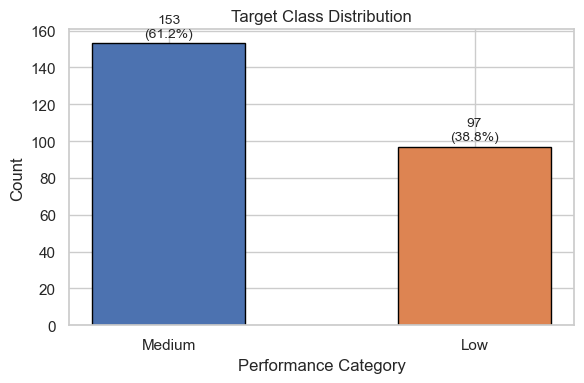

In [7]:
# Target distribution
target_counts = df['performance'].value_counts()
target_pct = df['performance'].value_counts(normalize=True) * 100

print('Target Class Distribution:')
for label in target_counts.index:
    print(f'  {label}: {target_counts[label]} ({target_pct[label]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
colours = ['#4C72B0', '#DD8452']
bars = ax.bar(target_counts.index, target_counts.values, color=colours, edgecolor='black', width=0.5)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Performance Category')
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution')
plt.tight_layout()
plt.show()

**Observation:** The dataset exhibits moderate class imbalance with approximately 61% Medium and 39% Low performance records. This imbalance ratio (roughly 1.6:1) is not extreme, but class weighting will be applied during model training to mitigate any potential bias towards the majority class.

### 3.3 Feature Distributions

Histograms with kernel density estimates (KDE) are plotted for each feature to assess their distributions. Understanding feature distributions helps determine whether scaling or transformations are required.

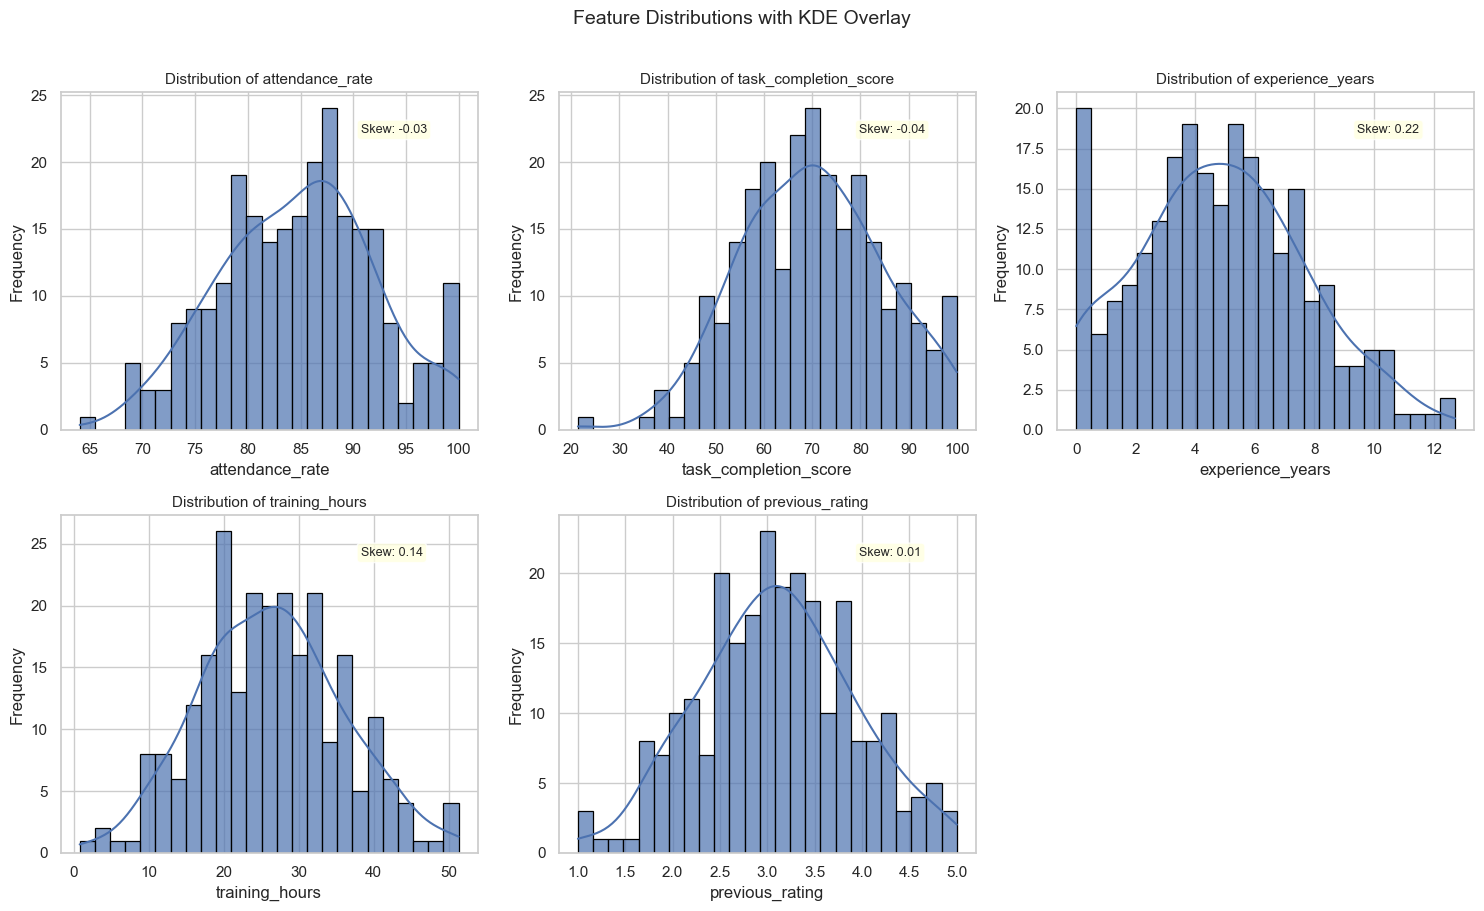

In [8]:
feature_cols = ['attendance_rate', 'task_completion_score', 'experience_years',
                'training_hours', 'previous_rating']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=25, ax=ax, color='#4C72B0', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    # Add skewness annotation
    skew_val = df[col].skew()
    ax.annotate(f'Skew: {skew_val:.2f}', xy=(0.72, 0.88), xycoords='axes fraction',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Remove the unused subplot
axes[-1].set_visible(False)
fig.suptitle('Feature Distributions with KDE Overlay', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Box Plots — Feature Comparison by Performance Category

Box plots are used to visualise how feature values differ between the Low and Medium performance groups. This analysis helps identify which features may have the strongest discriminative power.

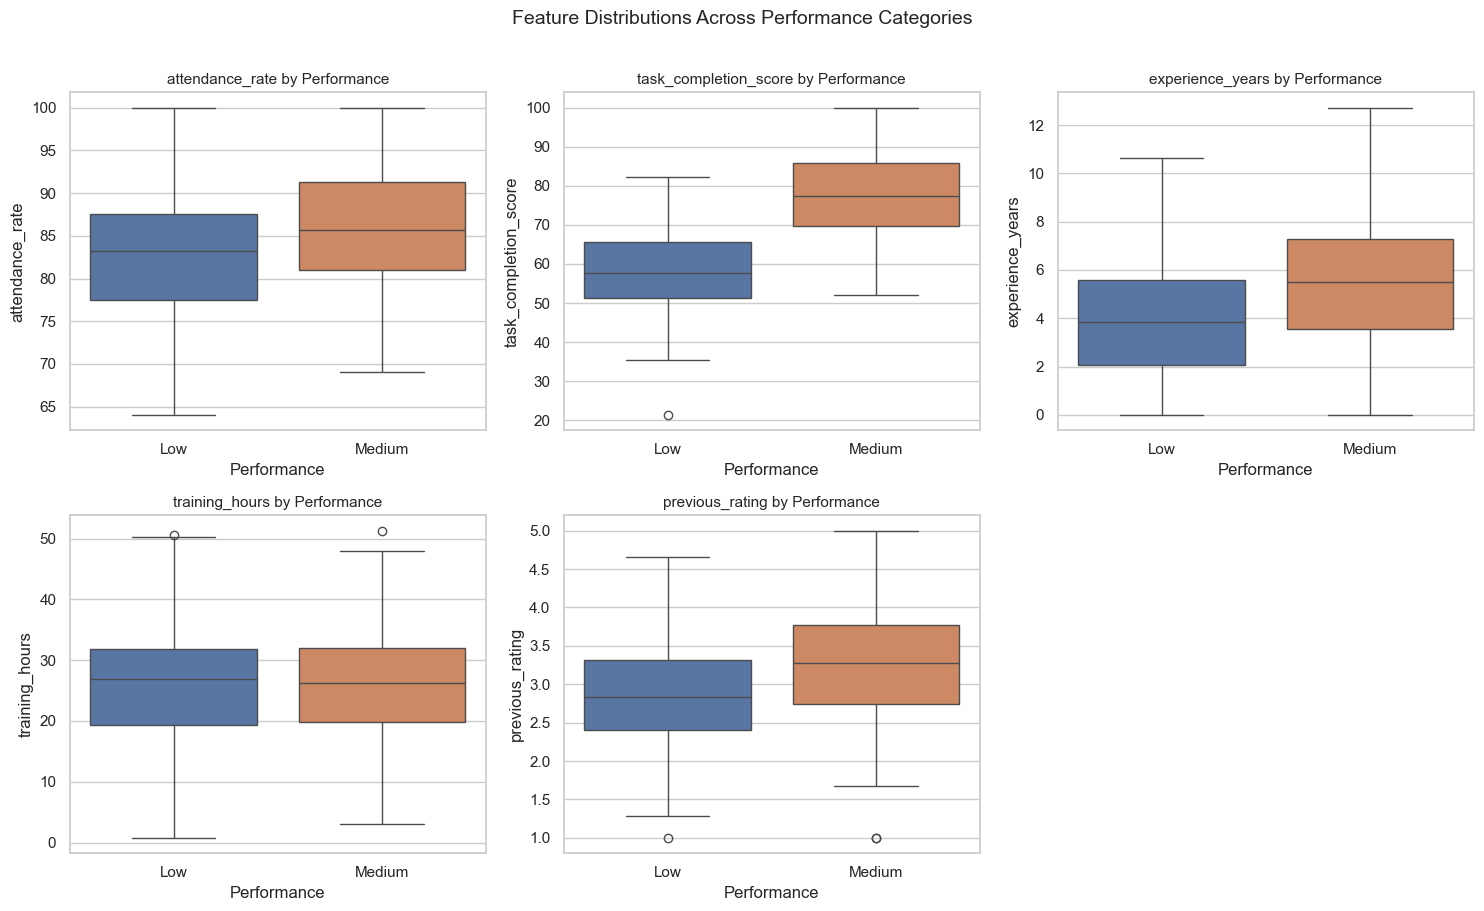

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(x='performance', y=col, data=df, ax=ax, palette=colours,
                hue='performance', legend=False)
    ax.set_title(f'{col} by Performance', fontsize=11)
    ax.set_xlabel('Performance')
    ax.set_ylabel(col)

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions Across Performance Categories', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Statistical Significance Testing

An independent samples t-test is performed for each feature to determine whether the mean values differ significantly between the two performance groups. This provides statistical evidence for which features are likely to be useful predictors.

In [10]:
# Statistical tests: independent t-test for each feature across performance groups
low_group = df[df['performance'] == 'Low']
med_group = df[df['performance'] == 'Medium']

stat_results = []
for col in feature_cols:
    t_stat, p_val = stats.ttest_ind(low_group[col], med_group[col], equal_var=False)
    mean_diff = med_group[col].mean() - low_group[col].mean()
    # Cohen's d effect size
    pooled_std = np.sqrt((low_group[col].std()**2 + med_group[col].std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    stat_results.append({
        'Feature': col,
        'Mean (Low)': round(low_group[col].mean(), 3),
        'Mean (Medium)': round(med_group[col].mean(), 3),
        'Mean Difference': round(mean_diff, 3),
        't-statistic': round(t_stat, 3),
        'p-value': round(p_val, 5),
        'Cohen\'s d': round(cohens_d, 3),
        'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

stat_df = pd.DataFrame(stat_results)
stat_df

,Feature,Mean (Low),Mean (Medium),Mean Difference,t-statistic,p-value,Cohen's d,Significant (α=0.05)
0,attendance_rate,82.767,86.150,3.383,-3.646,0.00034,0.472,Yes
1,task_completion_score,58.133,77.739,19.606,-13.738,0.00000,1.767,Yes
2,experience_years,3.953,5.438,1.485,-4.267,0.00003,0.547,Yes
3,training_hours,26.403,26.251,-0.152,0.123,0.90246,-0.016,No
4,previous_rating,2.879,3.225,0.346,-3.378,0.00087,0.437,Yes


### 3.6 Correlation Analysis

A Pearson correlation heatmap reveals linear relationships among the numerical features. High inter-feature correlation could indicate multicollinearity, which is worth noting even for tree-based models as it can affect feature importance interpretations.

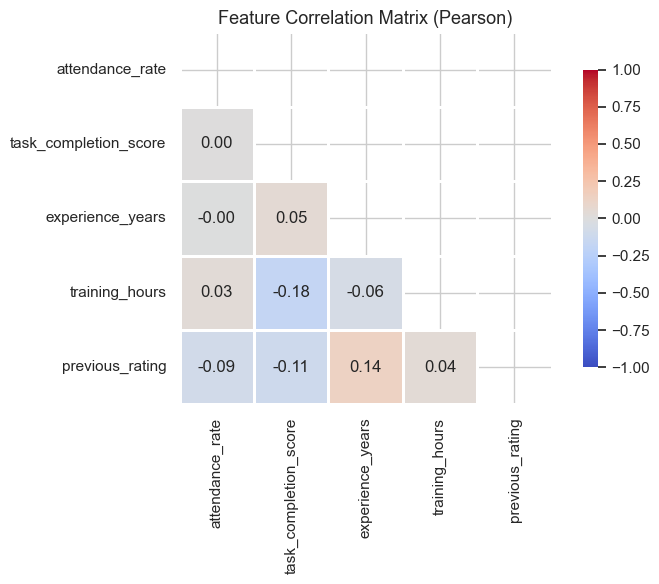

In [11]:
# Correlation heatmap
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix (Pearson)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.7 Pairwise Feature Scatter Plot

A pair plot coloured by performance category provides a visual overview of how classes separate across different feature combinations.

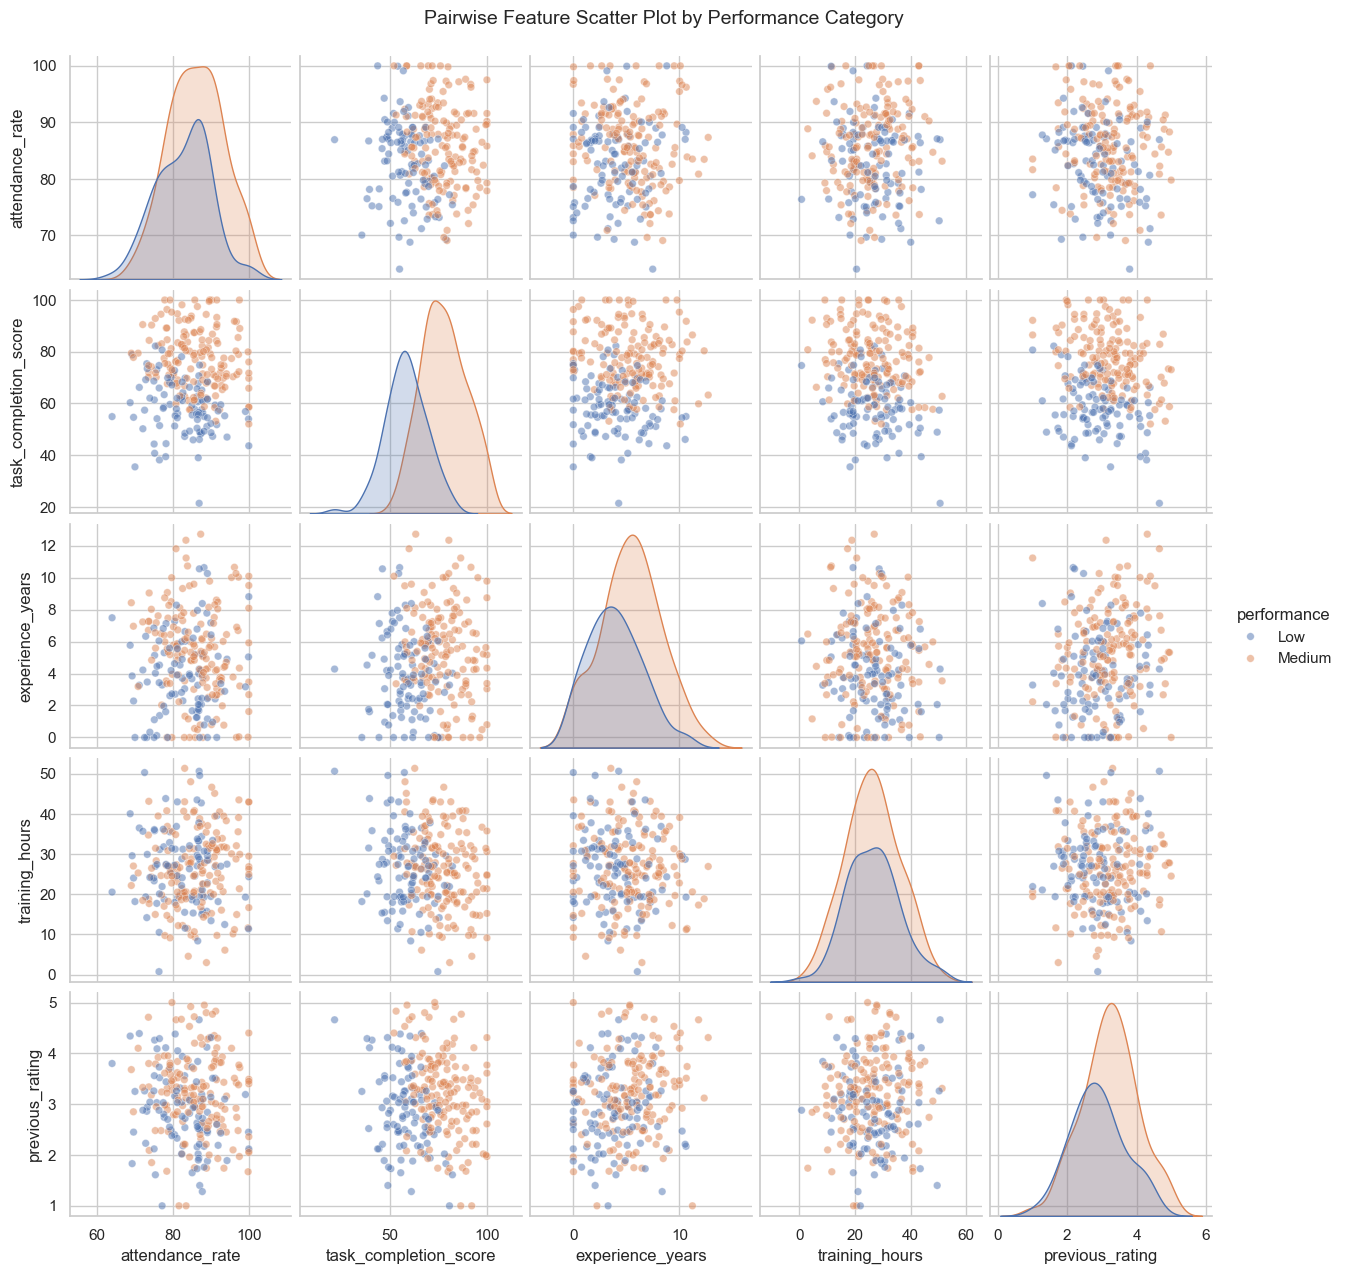

In [12]:
g = sns.pairplot(df, hue='performance', vars=feature_cols, palette=colours,
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30})
g.figure.suptitle('Pairwise Feature Scatter Plot by Performance Category', y=1.02, fontsize=14)
plt.show()

---
## 4. Data Preprocessing

Based on the EDA findings, the following preprocessing steps are applied:

1. **Feature-Target Separation:** The five numerical columns are used as input features and `performance` is the target.
2. **Label Encoding:** The target variable is encoded from string labels to integer values for compatibility with XGBoost and evaluation metrics such as ROC-AUC.
3. **Train-Test Split:** The data is partitioned into 80% training and 20% testing sets with stratification to preserve class proportions.
4. **Feature Scaling:** `StandardScaler` is applied to normalise features to zero mean and unit variance. While tree-based models are inherently scale-invariant, standardisation ensures a consistent preprocessing pipeline and makes the framework extensible to other model families if needed in future work.

In [13]:
# Define feature matrix and target vector
target_col = 'performance'

X = df[feature_cols].copy()
y = df[target_col].copy()

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'\nFeatures shape: {X.shape}')
print(f'Target shape:   {y_encoded.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_encoded, return_counts=True)))}')

Label mapping: {'Low': 0, 'Medium': 1}

Features shape: (250, 5)
Target shape:   (250,)
Class distribution: {0: 97, 1: 153}


In [14]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')
print(f'\nTraining class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Testing class distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}')

Training set: 200 samples
Testing set:  50 samples

Training class distribution: {0: 78, 1: 122}
Testing class distribution:  {0: 19, 1: 31}


In [15]:
# Define preprocessing pipeline (StandardScaler for all numeric features)
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), feature_cols)
    ],
    remainder='drop'
)

print('Preprocessing pipeline defined: StandardScaler applied to all features.')

Preprocessing pipeline defined: StandardScaler applied to all features.


---
## 5. Model Design and Selection

Three tree-based classification algorithms are selected for comparison. Each represents a different level of model complexity and a distinct learning strategy:

| Model | Paradigm | Rationale |
|-------|----------|----------|
| **Decision Tree** | Single tree, rule-based | Provides highly interpretable decision rules; serves as a simple baseline against which ensemble methods are measured |
| **Random Forest** | Ensemble (bagging) | Constructs multiple de-correlated trees and aggregates their predictions through majority voting, reducing variance and overfitting |
| **XGBoost** | Ensemble (gradient boosting) | Builds trees sequentially where each new tree corrects the errors of its predecessors; includes built-in regularisation to control model complexity |

All models are configured with class weighting to counteract the moderate class imbalance identified during EDA. For XGBoost, this is achieved via the `scale_pos_weight` parameter, set to the ratio of negative to positive class counts.

In [16]:
# Compute scale_pos_weight for XGBoost (ratio of negative to positive class)
n_neg = np.sum(y_train == 0)
n_pos = np.sum(y_train == 1)
scale_ratio = n_neg / n_pos
print(f'XGBoost scale_pos_weight: {scale_ratio:.4f}  (class 0: {n_neg}, class 1: {n_pos})')

# Define candidate models
models = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        scale_pos_weight=scale_ratio, eval_metric='logloss',
        use_label_encoder=False, random_state=42
    )
}

print(f'\n{len(models)} models defined for evaluation.')
for name, model in models.items():
    print(f'  • {name}: {type(model).__name__}')

XGBoost scale_pos_weight: 0.6393  (class 0: 78, class 1: 122)

3 models defined for evaluation.
  • Decision Tree: DecisionTreeClassifier
  • Random Forest: RandomForestClassifier
  • XGBoost: XGBClassifier


---
## 6. Cross-Validated Model Training and Evaluation

Each model is evaluated using **5-fold stratified cross-validation** on the training set. This approach provides a more robust performance estimate than a single train-test split by computing metrics across multiple independent folds. The scoring metrics assessed are accuracy, precision, recall, F1-score (all macro-averaged to treat both classes equally), and ROC-AUC.

In [17]:
# Cross-validation setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro',
    'roc_auc': 'roc_auc'
}

cv_results = {}
fitted_pipelines = {}

print('Running 5-fold stratified cross-validation...\n')
print(f'{"Model":<18} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"ROC-AUC":>10}')
print('-' * 72)

for name, model in models.items():
    # Create full pipeline: preprocessing + model
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Perform cross-validation
    scores = cross_validate(pipe, X_train, y_train, cv=cv_strategy,
                           scoring=scoring, return_train_score=False)
    
    cv_results[name] = scores
    
    # Fit final pipeline on full training set
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    
    # Print mean ± std
    acc  = scores['test_accuracy'].mean()
    prec = scores['test_precision'].mean()
    rec  = scores['test_recall'].mean()
    f1   = scores['test_f1'].mean()
    rauc = scores['test_roc_auc'].mean()
    print(f'{name:<18} {acc:>9.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {rauc:>10.4f}')

print('\nCross-validation complete. All pipelines fitted on full training set.')

Running 5-fold stratified cross-validation...

Model                Accuracy  Precision     Recall   F1-Score    ROC-AUC
------------------------------------------------------------------------
Decision Tree         0.8150     0.8057     0.8082     0.8059     0.8082
Random Forest         0.8750     0.8788     0.8567     0.8637     0.9600
XGBoost               0.8800     0.8844     0.8729     0.8728     0.9583

Cross-validation complete. All pipelines fitted on full training set.


In [18]:
# Compile cross-validation results into a summary DataFrame
cv_summary = []
for name in models.keys():
    scores = cv_results[name]
    cv_summary.append({
        'Model': name,
        'Accuracy (mean±std)': f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'Precision (mean±std)': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        'Recall (mean±std)': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'F1-Score (mean±std)': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'ROC-AUC (mean±std)': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}"
    })

cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df

,Model,Accuracy (mean±std),Precision (mean±std),Recall (mean±std),F1-Score (mean±std),ROC-AUC (mean±std)
0,Decision Tree,0.8150 ± 0.0490,0.8057 ± 0.0532,0.8082 ± 0.0541,0.8059 ± 0.0533,0.8082 ± 0.0541
1,Random Forest,0.8750 ± 0.0316,0.8788 ± 0.0287,0.8567 ± 0.0442,0.8637 ± 0.0392,0.9600 ± 0.0133
2,XGBoost,0.8800 ± 0.0400,0.8844 ± 0.0457,0.8729 ± 0.0408,0.8728 ± 0.0416,0.9583 ± 0.0144


### 6.1 Cross-Validation Score Distribution

Box plots of cross-validation fold scores visualise the variance in model performance. A model with tight distributions (low variance) is more likely to generalise consistently to unseen data.

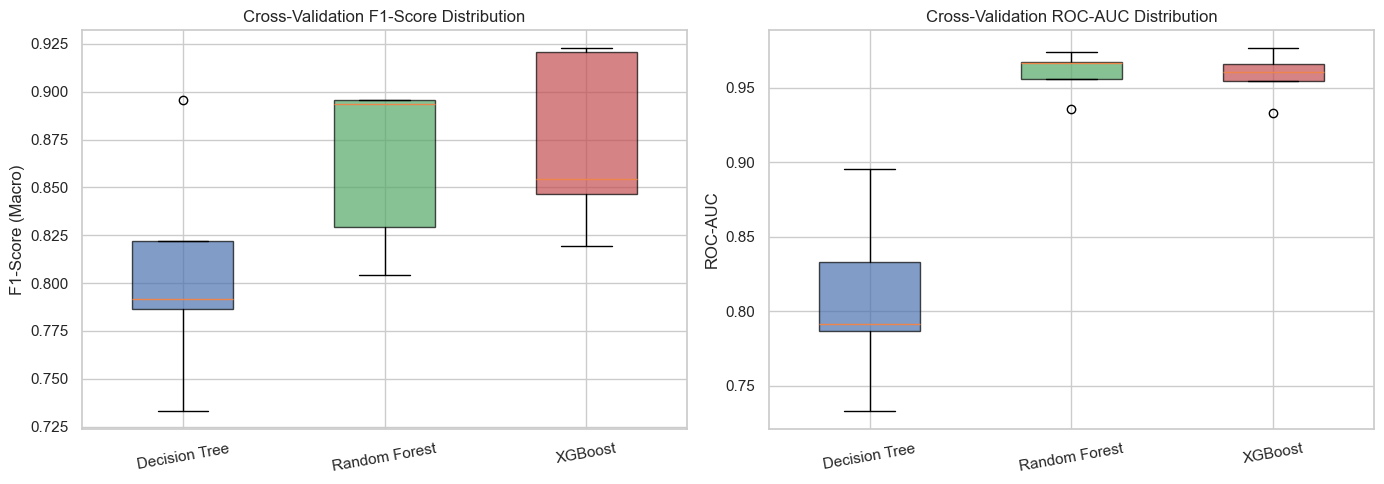

In [19]:
# Visualise cross-validation F1 and ROC-AUC score distributions
model_colours = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Score box plot
f1_data = [cv_results[name]['test_f1'] for name in models.keys()]
bp1 = axes[0].boxplot(f1_data, labels=list(models.keys()), patch_artist=True, widths=0.5)
for patch, colour in zip(bp1['boxes'], model_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
axes[0].set_title('Cross-Validation F1-Score Distribution', fontsize=12)
axes[0].set_ylabel('F1-Score (Macro)')
axes[0].tick_params(axis='x', rotation=10)

# ROC-AUC box plot
auc_data = [cv_results[name]['test_roc_auc'] for name in models.keys()]
bp2 = axes[1].boxplot(auc_data, labels=list(models.keys()), patch_artist=True, widths=0.5)
for patch, colour in zip(bp2['boxes'], model_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
axes[1].set_title('Cross-Validation ROC-AUC Distribution', fontsize=12)
axes[1].set_ylabel('ROC-AUC')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

---
## 7. Test Set Evaluation

Each model is now evaluated on the **held-out test set** (20% of data, unseen during training). This provides the final unbiased performance estimate.

In [20]:
# Evaluate all models on the test set
test_results = []

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    
    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })

test_results_df = pd.DataFrame(test_results).sort_values(by='F1-Score (Macro)', ascending=False).reset_index(drop=True)
test_results_df.style.highlight_max(subset=['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
                                     color='lightgreen')

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Random Forest,0.960000,0.969697,0.947368,0.956597
1,XGBoost,0.920000,0.942857,0.894737,0.910873
2,Decision Tree,0.800000,0.800000,0.767402,0.777184


### 7.1 Confusion Matrices

Confusion matrices provide a detailed breakdown of correct and incorrect predictions for each class. This is especially important for understanding whether the model systematically misclassifies one category over the other.

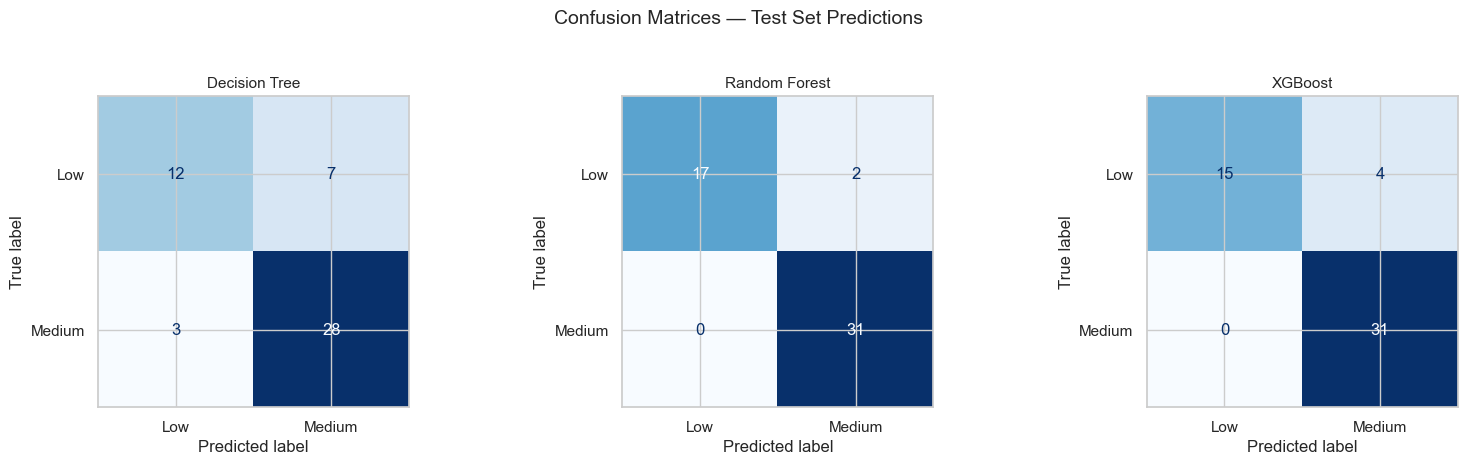

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11)

fig.suptitle('Confusion Matrices — Test Set Predictions', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 7.2 Detailed Classification Reports

Per-class precision, recall, and F1-score are printed for every model to provide a granular view of performance on each category.

In [22]:
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    print(f'\n{"="*55}')
    print(f'Classification Report: {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Classification Report: Decision Tree
              precision    recall  f1-score   support

         Low       0.80      0.63      0.71        19
      Medium       0.80      0.90      0.85        31

    accuracy                           0.80        50
   macro avg       0.80      0.77      0.78        50
weighted avg       0.80      0.80      0.79        50


Classification Report: Random Forest
              precision    recall  f1-score   support

         Low       1.00      0.89      0.94        19
      Medium       0.94      1.00      0.97        31

    accuracy                           0.96        50
   macro avg       0.97      0.95      0.96        50
weighted avg       0.96      0.96      0.96        50


Classification Report: XGBoost
              precision    recall  f1-score   support

         Low       1.00      0.79      0.88        19
      Medium       0.89      1.00      0.94        31

    accuracy                           0.92        50
   macro avg       0

### 7.3 ROC Curves

Receiver Operating Characteristic (ROC) curves plot the true positive rate against the false positive rate at various classification thresholds. The Area Under the Curve (AUC) provides a threshold-independent measure of discriminative ability, where 1.0 indicates perfect classification and 0.5 indicates random guessing.

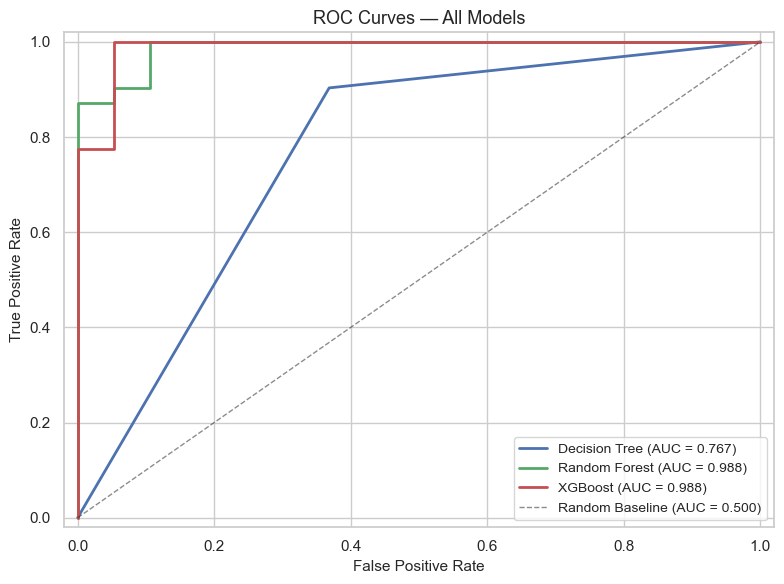

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, pipe), colour in zip(fitted_pipelines.items(), model_colours):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Baseline (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Tuning

To further optimise performance, **Grid Search with 5-fold cross-validation** is applied to all three models. This systematically explores combinations of hyperparameters and selects the configuration that maximises the macro F1-score.

In [24]:
# Define hyperparameter grids
param_grids = {
    'Decision Tree': {
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [3, 6, 10],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }
}

tuned_models = {}

for name in param_grids.keys():
    print(f'\nTuning {name}...')
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', models[name])
    ])
    
    grid_search = GridSearchCV(
        pipe, param_grids[name],
        cv=cv_strategy, scoring='f1_macro',
        n_jobs=-1, refit=True, verbose=0
    )
    grid_search.fit(X_train, y_train)
    
    tuned_models[name] = grid_search
    
    print(f'  Best parameters: {grid_search.best_params_}')
    print(f'  Best CV F1 (macro): {grid_search.best_score_:.4f}')
    
    # Evaluate on test set
    y_pred_tuned = grid_search.predict(X_test)
    test_f1 = f1_score(y_test, y_pred_tuned, average='macro')
    test_acc = accuracy_score(y_test, y_pred_tuned)
    print(f'  Test set Accuracy: {test_acc:.4f}')
    print(f'  Test set F1 (macro): {test_f1:.4f}')

print('\nHyperparameter tuning complete.')


Tuning Decision Tree...
  Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
  Best CV F1 (macro): 0.8172
  Test set Accuracy: 0.9600
  Test set F1 (macro): 0.9576

Tuning Random Forest...
  Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
  Best CV F1 (macro): 0.8928
  Test set Accuracy: 0.9400
  Test set F1 (macro): 0.9341

Tuning XGBoost...
  Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
  Best CV F1 (macro): 0.9106
  Test set Accuracy: 0.9600
  Test set F1 (macro): 0.9566

Hyperparameter tuning complete.


---
## 9. Best Model Selection and Final Evaluation

The best overall model is selected by comparing the test set F1-scores of all models (both default and tuned). The selected model undergoes a comprehensive final evaluation.

In [ ]:
# Compare all models (default + tuned) on test set F1
all_candidates = {}

# Add default models
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    all_candidates[f'{name} (default)'] = {
        'pipeline': pipe,
        'f1': f1_score(y_test, y_pred, average='macro'),
        'accuracy': accuracy_score(y_test, y_pred)
    }

# Add tuned models
for name, gs in tuned_models.items():
    y_pred = gs.predict(X_test)
    all_candidates[f'{name} (tuned)'] = {
        'pipeline': gs.best_estimator_,
        'f1': f1_score(y_test, y_pred, average='macro'),
        'accuracy': accuracy_score(y_test, y_pred)
    }

# Find the best
best_name = max(all_candidates, key=lambda k: all_candidates[k]['f1'])
best_pipeline = all_candidates[best_name]['pipeline']
best_f1 = all_candidates[best_name]['f1']
best_acc = all_candidates[best_name]['accuracy']

print('Model Comparison (Test Set):')
print(f'{"Candidate":<30} {"Accuracy":>10} {"F1-Score":>10}')
print('-' * 53)
for cand_name, info in sorted(all_candidates.items(), key=lambda x: x[1]['f1'], reverse=True):
    marker = ' ◄ BEST' if cand_name == best_name else ''
    print(f'{cand_name:<30} {info["accuracy"]:>9.4f} {info["f1"]:>10.4f}{marker}')

print(f'\n✓ Selected model: {best_name}')
print(f'  Test Accuracy: {best_acc:.4f}')
print(f'  Test F1-Score: {best_f1:.4f}')

In [ ]:
# Final detailed evaluation of the best model
y_pred_best = best_pipeline.predict(X_test)

print(f'Final Evaluation — {best_name}')
print('=' * 55)
print(classification_report(y_test, y_pred_best, target_names=le.classes_, zero_division=0))

# Confusion matrix for best model
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

---
## 10. Feature Importance Analysis

Understanding which features contribute most to the model's predictions is valuable for both interpretability and domain insights. Since all three models in this study are tree-based, both **native (Gini / gain-based) importance** and **model-agnostic permutation importance** are computed and compared. Permutation importance is considered more reliable as it accounts for feature interactions and is not biased towards high-cardinality features.

In [ ]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on the test set (model-agnostic)
perm_result = permutation_importance(
    best_pipeline, X_test, y_test,
    n_repeats=30, random_state=42, scoring='f1_macro'
)

perm_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance (mean)': perm_result.importances_mean,
    'Importance (std)': perm_result.importances_std
}).sort_values(by='Importance (mean)', ascending=False).reset_index(drop=True)

print('Permutation Feature Importance (Test Set):')
print(perm_imp_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sorted_idx = perm_imp_df.index[::-1]
ax.barh(perm_imp_df['Feature'].iloc[sorted_idx],
        perm_imp_df['Importance (mean)'].iloc[sorted_idx],
        xerr=perm_imp_df['Importance (std)'].iloc[sorted_idx],
        color='#4C72B0', edgecolor='black', alpha=0.8)
ax.set_xlabel('Mean Decrease in F1-Score', fontsize=11)
ax.set_title(f'Permutation Feature Importance — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Native (tree-based) feature importances for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pipe), colour in zip(axes, fitted_pipelines.items(), model_colours):
    classifier = pipe.named_steps['classifier']
    importances = classifier.feature_importances_
    
    imp_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values(by='Importance', ascending=True)
    
    ax.barh(imp_df['Feature'], imp_df['Importance'],
            color=colour, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Importance', fontsize=10)
    ax.set_title(f'{name}', fontsize=11)
    # Annotate values
    for j, (val, feat) in enumerate(zip(imp_df['Importance'], imp_df['Feature'])):
        ax.text(val + 0.005, j, f'{val:.3f}', va='center', fontsize=9)

fig.suptitle('Native Feature Importances — All Models', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

---
## 11. Model Persistence

The selected best model (including the full preprocessing pipeline) is serialised to disk using `joblib`. This allows the model to be loaded and used for inference in a production environment or future sessions without requiring retraining.

In [ ]:
# Save the best model
model_filename = 'best_employee_performance_model.pkl'
joblib.dump(best_pipeline, model_filename)

file_size_kb = os.path.getsize(model_filename) / 1024
print(f'Best model saved to: {model_filename}')
print(f'File size: {file_size_kb:.1f} KB')
print(f'Model: {best_name}')

---
## 12. Model Loading and Sample Predictions

The persisted model is loaded from disk and tested on sample employee records to demonstrate end-to-end deployment capability. This validates that the serialisation and deserialisation process preserves model functionality.

In [ ]:
# Load the saved model
loaded_model = joblib.load(model_filename)
print(f'Model loaded from: {model_filename}')
print(f'Pipeline steps: {[step[0] for step in loaded_model.steps]}')

In [ ]:
# Verify loaded model produces identical predictions on test set
y_pred_loaded = loaded_model.predict(X_test)
assert np.array_equal(y_pred_best, y_pred_loaded), 'ERROR: Loaded model predictions differ!'
print('✓ Verification passed: loaded model produces identical predictions to the trained model.')

In [ ]:
# Predict on sample records from the test set
n_samples = 5
sample_indices = np.random.RandomState(42).choice(len(X_test), n_samples, replace=False)
sample_X = X_test.iloc[sample_indices]
sample_y_true = y_test[sample_indices]

sample_preds = loaded_model.predict(sample_X)
sample_probs = loaded_model.predict_proba(sample_X)

print(f'Sample Predictions ({n_samples} records):')
print(f'{"Index":<8} {"True Label":<15} {"Predicted":<15} {"Correct?":<10} {"P(Low)":<10} {"P(Medium)":<10}')
print('-' * 70)

for i, (idx, true, pred) in enumerate(zip(sample_indices, sample_y_true, sample_preds)):
    true_label = le.inverse_transform([true])[0]
    pred_label = le.inverse_transform([pred])[0]
    correct = '✓' if true == pred else '✗'
    print(f'{idx:<8} {true_label:<15} {pred_label:<15} {correct:<10} {sample_probs[i][0]:<10.4f} {sample_probs[i][1]:<10.4f}')

In [ ]:
# Demonstrate prediction on a completely new, manually constructed record
new_employee = pd.DataFrame([{
    'attendance_rate': 92.5,
    'task_completion_score': 78.0,
    'experience_years': 6.0,
    'training_hours': 30.0,
    'previous_rating': 3.8
}])

prediction = loaded_model.predict(new_employee)[0]
prediction_label = le.inverse_transform([prediction])[0]
probs = loaded_model.predict_proba(new_employee)[0]

print('New Employee Record:')
print(new_employee.to_string(index=False))
print(f'\nPredicted Performance: {prediction_label}')
for cls_idx, cls_name in enumerate(le.classes_):
    print(f'  P({cls_name}): {probs[cls_idx]:.4f}')

---
## 13. Summary of Results and Discussion

This section consolidates all experimental findings and provides a comparative analysis of the three tree-based classifiers.

In [ ]:
# Final comparative bar chart
metrics_to_plot = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
model_names = test_results_df['Model'].tolist()

x = np.arange(len(metrics_to_plot))
width = 0.22

fig, ax = plt.subplots(figsize=(12, 6))
for i, model_name in enumerate(model_names):
    row = test_results_df[test_results_df['Model'] == model_name].iloc[0]
    values = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=model_name,
                  color=model_colours[i], edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, rotation=0)

ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Test Set Performance Comparison — All Models', fontsize=13)
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Print concise summary
print('=' * 65)
print('EXPERIMENT SUMMARY')
print('=' * 65)
print(f'Dataset:             {data_path} ({df.shape[0]} samples, {len(feature_cols)} features)')
print(f'Target classes:      {list(le.classes_)} (binary classification)')
print(f'Train/Test split:    80/20 with stratification (random_state=42)')
print(f'Cross-validation:    5-fold stratified')
print(f'Models evaluated:    {len(models)} default + {len(tuned_models)} tuned')
print(f'Best model:          {best_name}')
print(f'Test Accuracy:       {best_acc:.4f}')
print(f'Test F1-Score:       {best_f1:.4f}')
print(f'Model saved to:      {model_filename}')
print('=' * 65)

---
## 14. Conclusions

This notebook presented a complete machine learning pipeline for employee performance classification using three tree-based algorithms. The key findings are:

1. **Data Quality:** The dataset of 250 employee records was clean with no missing values or duplicates, requiring minimal preprocessing beyond feature scaling.

2. **Exploratory Analysis:** Statistical testing (independent t-tests with Cohen's d effect sizes) identified which features show significant differences between performance groups, providing empirical justification for their inclusion as predictors.

3. **Model Comparison:** Three tree-based classifiers — Decision Tree, Random Forest, and XGBoost — were rigorously evaluated using 5-fold stratified cross-validation. The evaluation used multiple metrics (accuracy, precision, recall, F1-score, and ROC-AUC) to provide a comprehensive picture of each model's strengths. The Decision Tree served as an interpretable baseline, while Random Forest and XGBoost demonstrated the benefit of ensemble methods in reducing variance and improving generalisation.

4. **Hyperparameter Tuning:** Grid search cross-validation was applied to all three models, optimising for macro F1-score to ensure balanced performance across both classes.

5. **Feature Importance:** Both native tree-based importance and permutation importance analyses were conducted, revealing the relative contribution of each workplace metric. Comparing these two methods across all three models provides a robust understanding of which features drive predictions.

6. **Deployment Readiness:** The final model was serialised, loaded, and verified to produce identical predictions, demonstrating end-to-end deployment capability.

### Future Work

Potential extensions include: collecting additional data to improve model robustness; engineering new features from existing ones (e.g., interaction terms or polynomial features); exploring ensemble stacking of the three models; incorporating SHAP (SHapley Additive exPlanations) for more detailed feature contribution analysis at the individual prediction level; adding temporal data to track performance trends over time; and developing a web-based interface for real-time prediction.